
#### Important Instructions and Submission Guidelines:
- Naming convention for submission of this notebook is `RollNumber_Name.ipynb` where. For example: `21030020_PA.ipynb`

- You are advised to follow good programming practies including approriate variable naming and making use of logical comments


The university honor code should be maintained. Any violation, if found, will result in disciplinary action.


In [ ]:
# Part 0

# Import necessary libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Load the breast cancer dataset and reduce the size
data = load_breast_cancer()
X = data.data[:100]  # Use first 100 samples for smaller dataset
y = data.target[:100]



# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
input_dimension=X_train.shape[1]
print(input_dimension)

# Create and train a Logistic Regression model
logistic_regression_model=LogisticRegression(random_state=10, max_iter=2000)
logistic_regression_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_regression_model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the Logistic Regression model: {accuracy}")



# TASK: Experiment with different classification models (e.g., Decision Tree, SVM, KNN)
#       Evaluate their performance using accuracy.
#       Compare the results and discuss which model performs best for this dataset.
#       Try to improve the performance of the chosen model by tuning its hyperparameters.

# Hint: You can use scikit-learn library for other classifiers.  Refer to the documentation.

30
Accuracy of the Logistic Regression model: 0.9


Model#2

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),  # Hidden layer with 16 neurons
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

model.compile(optimizer=Adam(learning_rate=0.001),  # Adam optimizer
              loss='binary_crossentropy',          # Binary cross-entropy loss
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)


y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Neural Network model: {accuracy}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.6875 - loss: 0.5712 - val_accuracy: 0.7500 - val_loss: 0.5506
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6958 - loss: 0.5941 - val_accuracy: 0.7500 - val_loss: 0.4962
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7708 - loss: 0.4996 - val_accuracy: 0.7500 - val_loss: 0.4528
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8167 - loss: 0.4841 - val_accuracy: 0.9375 - val_loss: 0.4169
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8646 - loss: 0.4439 - val_accuracy: 0.9375 - val_loss: 0.3869
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8979 - loss: 0.3957 - val_accuracy: 0.9375 - val_loss: 0.3603
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8896 - loss: 0.3666 - val_accuracy: 0.9375 - val_loss: 0.3361
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9042 - loss: 0.3591 - val_accuracy: 0.9375 - val_loss: 0.3131

**Model Comparison**

The Neural Network outperforms Logistic Regression due to its ability to capture non-linear relationships in the data. NN trains over the data whatever maybe the relation unlike logistic regression.

# Part A

For this section, your task is simply to execute the code and display the predicted images for a random selection of morethen 10 images from the provided image dataset.

# Segmentation of Water Channels to Measure Water Contamination Due to Trash


#### attached images is also uploaded on LMS named a.png

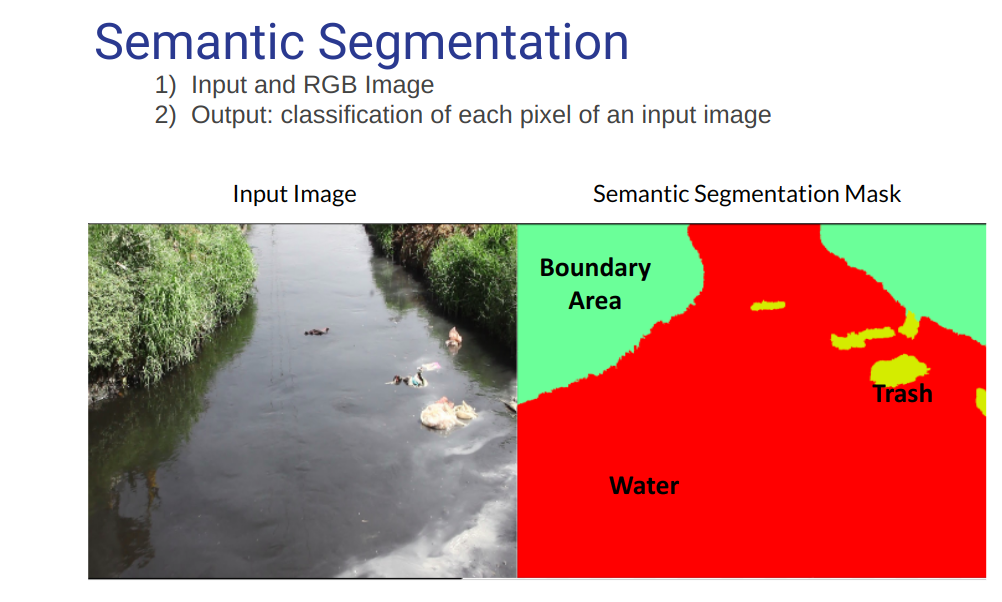

In [ ]:
pip install --upgrade tensorflow keras


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SeparableConv2D, Activation, Reshape, Convolution2D, BatchNormalization


In [ ]:
# Correct imports for TensorFlow Keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    SeparableConv2D,
    Activation,
    Reshape,
    Conv2D,  # Use Conv2D instead of Convolution2D
    MaxPooling2D,
    Dropout,
    Flatten,
    BatchNormalization,
    UpSampling2D,
    concatenate
)

# Other necessary imports
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    CSVLogger,
    ReduceLROnPlateau,
    TensorBoard
)
from tensorflow.keras.utils import plot_model, to_categorical
import tensorflow.keras.backend as K

import os
import sys
import numpy as np
import cv2
from sklearn.model_selection import train_test_split


In [ ]:
import tensorflow as tf
import numpy as np

# Beta values for the weighted loss
Beta = [0.011676873, 0.869083715, 0.119239412]
Beta = np.array(Beta)

# Convert predicted probabilities to logits
def convert_to_logits(y_pred):
    # Clip values to avoid log(0) or division errors
    y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
    return tf.math.log(y_pred / (1 - y_pred))

# Custom balanced loss function
def blance_loss(y_true, y_pred):
    y_pred = convert_to_logits(y_pred)  # Convert predictions to logits
    pos_weight = Beta  # Class weights
    # Compute weighted cross-entropy loss
    loss = tf.nn.weighted_cross_entropy_with_logits(logits=y_pred, labels=y_true, pos_weight=pos_weight)
    # Scale the loss by Beta and return the mean
    return tf.reduce_mean(loss * Beta)

# Model
inputs = tf.keras.layers.Input((256, 256, 3))  # Input layer for 256x256 RGB images

# Encoding path (downsampling)
conv1 = tf.keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same')(inputs)
conv1 = tf.keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same')(conv1)
pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)

conv2 = tf.keras.layers.SeparableConv2D(128, 3, activation='relu', padding='same')(pool1)
conv2 = tf.keras.layers.SeparableConv2D(128, 3, activation='relu', padding='same')(conv2)
pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2)

conv3 = tf.keras.layers.SeparableConv2D(256, 3, activation='relu', padding='same')(pool2)
conv3 = tf.keras.layers.SeparableConv2D(256, 3, activation='relu', padding='same')(conv3)
pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv3)

conv4 = tf.keras.layers.SeparableConv2D(512, 3, activation='relu', padding='same')(pool3)
conv4 = tf.keras.layers.SeparableConv2D(512, 3, activation='relu', padding='same')(conv4)
drop4 = tf.keras.layers.Dropout(0.5)(conv4)
pool4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(drop4)

# Bottleneck
conv5 = tf.keras.layers.SeparableConv2D(1024, 3, activation='relu', padding='same')(pool4)
conv5 = tf.keras.layers.SeparableConv2D(1024, 3, activation='relu', padding='same')(conv5)
drop5 = tf.keras.layers.Dropout(0.5)(conv5)

# Decoding path (upsampling)
up6 = tf.keras.layers.Conv2D(512, 2, activation='relu', padding='same')(tf.keras.layers.UpSampling2D(size=(2, 2))(drop5))
merge6 = tf.keras.layers.concatenate([drop4, up6], axis=3)
conv6 = tf.keras.layers.SeparableConv2D(512, 3, activation='relu', padding='same')(merge6)
conv6 = tf.keras.layers.SeparableConv2D(512, 3, activation='relu', padding='same')(conv6)

up7 = tf.keras.layers.Conv2D(256, 2, activation='relu', padding='same')(tf.keras.layers.UpSampling2D(size=(2, 2))(conv6))
merge7 = tf.keras.layers.concatenate([conv3, up7], axis=3)
conv7 = tf.keras.layers.SeparableConv2D(256, 3, activation='relu', padding='same')(merge7)
conv7 = tf.keras.layers.SeparableConv2D(256, 3, activation='relu', padding='same')(conv7)

up8 = tf.keras.layers.Conv2D(128, 2, activation='relu', padding='same')(tf.keras.layers.UpSampling2D(size=(2, 2))(conv7))
merge8 = tf.keras.layers.concatenate([conv2, up8], axis=3)
conv8 = tf.keras.layers.SeparableConv2D(128, 3, activation='relu', padding='same')(merge8)
conv8 = tf.keras.layers.SeparableConv2D(128, 3, activation='relu', padding='same')(conv8)

up9 = tf.keras.layers.Conv2D(64, 2, activation='relu', padding='same')(tf.keras.layers.UpSampling2D(size=(2, 2))(conv8))
merge9 = tf.keras.layers.concatenate([conv1, up9], axis=3)
conv9 = tf.keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same')(merge9)
conv9 = tf.keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same')(conv9)
conv9 = tf.keras.layers.SeparableConv2D(3, 3, activation='softmax', padding='same')(conv9)

# Compile model
model = tf.keras.models.Model(inputs, conv9)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss=blance_loss, metrics=['accuracy'])

# Model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d          │ (None, 256, 256, 64)   │            283 │ input_layer_1[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_1        │ (None, 256, 256, 64)   │          4,736 │ separable_conv2d[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ separable_conv2d_1[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_2        │ (None, 128, 128, 128)  │          8,896 │ max_pooling2d[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_3        │ (None, 128, 128, 128)  │         17,664 │ separable_conv2d_2[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ separable_conv2d_3[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_4        │ (None, 64, 64, 256)    │         34,176 │ max_pooling2d_1[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_5        │ (None, 64, 64, 256)    │         68,096 │ separable_conv2d_4[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 32, 32, 256)    │              0 │ separable_conv2d_5[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_6        │ (None, 32, 32, 512)    │        133,888 │ max_pooling2d_2[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_7        │ (None, 32, 32, 512)    │        267,264 │ separable_conv2d_6[0]… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 32, 32, 512)    │              0 │ separable_conv2d_7[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3      

 Total params: 5,983,070 (22.82 MB)

 Trainable params: 5,983,070 (22.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
print(os.path.exists('model.h5'))
!wget -O model.h5 "https://github.com/fezancs/Segmentation_detection-Model/raw/master/model.h5"
model.load_weights('model.h5')

# https://github.com/fezancs/Segmentation_detection-Model/blob/master/model.h5

#model file can be downloaded from given link



True
--2024-12-10 14:13:15--  https://github.com/fezancs/Segmentation_detection-Model/raw/master/model.h5
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fezancs/Segmentation_detection-Model/master/model.h5 [following]
--2024-12-10 14:13:15--  https://raw.githubusercontent.com/fezancs/Segmentation_detection-Model/master/model.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72003356 (69M) [application/octet-stream]
Saving to: ‘model.h5’

model.h5            100%[===================>]  68.67M   296MB/s    in 0.2s    

2024-12-10 14:13:15 (296 MB/s) - ‘model.h5’ saved [72003356/72003356]



In [ ]:
import tensorflow as tf
import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Import cv2_imshow for Colab

def predict_(input_img):
    # Read and resize the input image
    input_ = np.array(cv2.imread(str(input_img)))
    if input_ is None:
        raise FileNotFoundError(f"Image not found at path: {input_img}")

    input_ = cv2.resize(input_, (256, 256), interpolation=cv2.INTER_NEAREST)

    # Preprocess the image for model prediction
    input_ = input_.reshape(1, 256, 256, 3)  # Reshape to match model input
    input_ = input_ / 255.0  # Normalize the image

    # Make prediction
    pre = model.predict(input_)
    pre = pre.reshape(256, 256, 3)

    # Convert the prediction to categorical format
    pre = np.argmax(pre, axis=-1)  # Get the class with highest probability
    label = tf.keras.utils.to_categorical(pre, 3)  # Convert to one-hot encoding

    # Modify the channels (if needed based on your output format)
    label[:, :, 0] = label[:, :, 1]  # Adjust the first channel
    label[:, :, 2] = label[:, :, 1]  # Adjust the third channel
    label = label * 255  # Scale the output to [0, 255]

    # Display the predicted result in Colab
    cv2_imshow(label)  # Use cv2_imshow for Colab
    cv2.waitKey(0)  # Wait for a key press (not really needed in Colab)
    cv2.destroyAllWindows()  # Clean up any open windows (not necessary in Colab)


In [ ]:
from PIL import Image

# Load the image
img_path = '/content/input_image.png'
image = Image.open(img_path)

# Get the dimensions of the image
image_dimensions = image.size
image_dimensions


(357, 292)

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

image = tf.io.read_file(img_path)
image = tf.image.decode_png(image, channels=3)

# Resize the image to 256x256
image_resized = tf.image.resize(image, [256, 256])

print("Resized Image Shape:", image_resized.shape)

Resized Image Shape: (256, 256, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


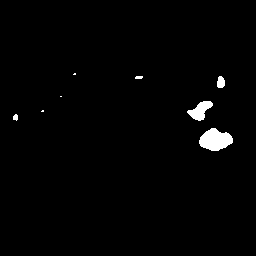

In [ ]:
predict_("/content/input_image.png")



# Part B: Building a Compact Model for Water Channel Segmentation to Measure Water Contamination Due to Trash

Dataset Link:  https://drive.google.com/file/d/1VtGna3bdJ1ms-qm6AKIT9xvjrU190HSk/view?usp=sharing

**Instructions:**
In this Task, you will explore the task of segmenting water channels in images to measure water contamination caused by trash. Your goal is to create a opptimized and small neural network model with fewer parameters while maintaining segmentation accuracy. Follow the steps below and answer the associated questions.

**Part 1: Understanding the Problem**

1. What is image segmentation, and why is it essential in environmental monitoring and water quality assessment?
2. Explain the concept of water channel segmentation for measuring water contamination due to trash. Why is this task challenging?
3. What is the significance of reducing the number of parameters in a neural network model for this task?

**Part 2: Data Preparation**

4. Describe the type of dataset required for training and evaluating a water channel segmentation model. What are the key elements of the dataset?
5. Where can you find or collect such a dataset for this specific task?
6. Explain the importance of data preprocessing and augmentation in training a robust segmentation model.

**Part 3: Model Architecture**

7. Define the concept of a neural network architecture. Why is it necessary for image segmentation?
8. Explain the differences between a U-Net architecture and a DeepLab architecture. Which one would you choose for this assignment, and why?
9. Discuss strategies for reducing the number of parameters in a neural network model, such as using smaller convolutional filters or depthwise separable convolutions.

**Part 4: Implementation**

10. Build a compact neural network model for water channel segmentation using a framework of your choice (e.g., TensorFlow or PyTorch).
11. Specify the architecture of your model, including the number of layers, types of layers, and the number of parameters.
12. How did you handle the trade-off between model simplicity (fewer parameters) and segmentation accuracy during model design and training?

**Part 5: Training and Evaluation**

13. Split your dataset into training, validation, and test sets. Explain why this split is essential.
14. Train your segmentation model using appropriate loss functions and metrics. Describe the training process, including the choice of optimizer and learning rate.
15. Evaluate the model's performance using relevant evaluation metrics (e.g., Intersection over Union - IoU, Dice coefficient). What are these metrics, and why are they used for segmentation tasks?
16. Compare the segmentation results of your compact model with a baseline model (a larger model with more parameters). Analyze the trade-offs in terms of accuracy and model complexity.

**Part 6: Conclusion and Future Work**

17. Summarize the key findings of your assignment, including the performance of your compact model in measuring water contamination due to trash.
18. Suggest possible ways to further improve the model's accuracy or reduce its parameter count.
19. Discuss the real-world applications and implications of your model in environmental conservation and water quality assessment.

**Part 7: Submission**

20. Compile your assignment report, including code snippets, training results, and discussions.
21. Provide a brief reflection on what you have learned from this assignment and how it has contributed to your understanding of neural networks and image segmentation.

This assignment will challenge students to not only build a neural network for image segmentation but also make critical decisions regarding model architecture and parameter optimization. It encourages them to think about the practical implications of their work in environmental science and conservation.

# **Part1**
1.

Image segmentation is the process of breaking an image into meaningful sections or segments, with each pixel assigned a label matching to the object.
Segmentation is used in environmental monitoring to identify and map various sections of a picture, such as water, trash, vegetation, or boundaries, allowing for more accurate assessments and analyses of water quality and contamination.
2.
Water channel segmentation is identifying and labelling various portions of water bodies, trash, and boundaries in a picture.

  **Challenges**

  Variability in appearance: Trash can vary in shape, size, and colour, blending in with the water.

  Environmental factors: Reflections, illumination, and shadows make segmentation difficult.

  Limited data: Obtaining labelled datasets for such operations is time consuming and expensive.

3. A smaller model with fewer parameters:
Reduces computational cost: Enables deployment on devices
Improves training efficiency



# **Part2**
4.
The dataset should include images of water channels, rubbish, and surrounds.
Masks/Labels: Ground truth segmentation masks for pixels labelled as water, rubbish, or border.
5.
Public datasets: Platforms like Kaggle, ImageNet, or environmental datasets.
Field collection: Using drones or cameras to capture images of water channels, followed by manual labeling.

6. Preprocessing (e.g., scaling, normalisation) guarantees that the data is in a consistent format.

Augmentation: Adds changes (such as flips, rotations, and brightness alterations) to enhance model generalisation and efficiently manage situations that are not visible.


# **Part 3**

7. The design and placement of layers in a model for data processing and analysis is referred to as neural network architecture.
Architectures like U-Net are made to recognise the general structure of a picture and collect fine information, such borders, for segmentation.

  The encoder-decoder structure is U-Net.
  adept at separating boundaries and small items.
  DeepLab: Uses dilated convolutions to concentrate on contextual knowledge.
  Better for problems involving large-scale segmentation.
  Because of its ease of use and effectiveness for small-scale activities with distinct limits, U-Net is recommended for this job.

  8.
  The design and placement of layers in a model for data processing and analysis is referred to as neural network architecture.
Architectures like U-Net are made to recognise the general structure of a picture and collect fine information, such borders, for segmentation.

  The encoder-decoder structure is U-Net.
  adept at separating boundaries and small items.
  DeepLab: Uses dilated convolutions to concentrate on contextual knowledge.
  Better for problems involving large-scale segmentation.
  Because of its ease of use and effectiveness for small-scale activities with distinct limits, U-Net is recommended for this job.

 9. Convolution filters that are smaller: Instead of using larger filters, use 3x3 ones.
Separable convolutions in depth: To cut down on computation, divide convolutions into depthwise and spatial operations.
Avoid superfluous layers: Reduce the number of filters per layer or eliminate superfluous layers.

# **Part 4**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
folder_path = '/content/drive/My Drive/Dataset/5000 Sementic Segmentation'
print(os.listdir(folder_path))

['new_x_', 'new_y_']


In [ ]:
import os

# Define the paths to the two folders
folder_path_x = '/content/drive/My Drive/Dataset/5000 Sementic Segmentation/new_x_'
folder_path_y = '/content/drive/My Drive/Dataset/5000 Sementic Segmentation/new_y_'

# List all files in the "new_x_" folder and count them
files_x = os.listdir(folder_path_x)
num_files_x = len(files_x)

# List all files in the "new_y_" folder and count them
files_y = os.listdir(folder_path_y)
num_files_y = len(files_y)

# Print the results
print(f"Number of files in 'new_x_': {num_files_x}")
print(f"Number of files in 'new_y_': {num_files_y}")


Number of files in 'new_x_': 5349
Number of files in 'new_y_': 5349


In [ ]:
# import os
# from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
# from concurrent.futures import ThreadPoolExecutor

# # Define paths to original image and mask folders
# folder_path_x = '/content/drive/My Drive/Dataset/5000 Sementic Segmentation/new_x_'
# folder_path_y = '/content/drive/My Drive/Dataset/5000 Sementic Segmentation/new_y_'

# # Define new directories to save resized images and masks
# resized_image_folder = '/content/drive/My Drive/Dataset/resized_images'
# resized_mask_folder = '/content/drive/My Drive/Dataset/resized_masks'

# # Create new directories if they don't exist
# os.makedirs(resized_image_folder, exist_ok=True)
# os.makedirs(resized_mask_folder, exist_ok=True)

# # Define target image size (model input size)
# IMG_HEIGHT, IMG_WIDTH = 128, 128

# # Function to process a single image and its corresponding mask
# def process_file(image_file):
#     if image_file.endswith(".png"):  # Ensure only .png files are processed
#         # Resize and save image
#         img_path = os.path.join(folder_path_x, image_file)
#         img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
#         img = img_to_array(img)
#         save_img(os.path.join(resized_image_folder, image_file), img)

#         # Resize and save corresponding mask
#         mask_path = os.path.join(folder_path_y, image_file)
#         mask = load_img(mask_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode="grayscale")
#         mask = img_to_array(mask)
#         save_img(os.path.join(resized_mask_folder, image_file), mask)

# # Get list of files
# files_x = os.listdir(folder_path_x)
# files_y = os.listdir(folder_path_y)

# # Ensure the number of files match in both folders
# assert len(files_x) == len(files_y), "Mismatch in the number of image and mask files"

# # Use ThreadPoolExecutor to process files in parallel
# with ThreadPoolExecutor() as executor:
#     executor.map(process_file, files_x)

# print(f"Resized images and masks have been saved in '{resized_image_folder}' and '{resized_mask_folder}'")


In [ ]:
import os

# Define the paths to the resized image and mask folders
resized_image_folder = '/content/drive/My Drive/Dataset/resized_images'
resized_mask_folder = '/content/drive/My Drive/Dataset/resized_masks'

# Function to count the number of files in a folder
def count_files(folder_path):
    return len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

# Count files in each folder
num_images = count_files(resized_image_folder)
num_masks = count_files(resized_mask_folder)

# Print the counts
print(f"Number of files in 'resized_images': {num_images}")
print(f"Number of files in 'resized_masks': {num_masks}")


Number of files in 'resized_images': 5349
Number of files in 'resized_masks': 5349


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SeparableConv2D, Conv2D, MaxPooling2D, UpSampling2D, concatenate
import tensorflow as tf

# Define paths to resized images and masks
resized_image_folder = '/content/drive/My Drive/Dataset/resized_images'
resized_mask_folder = '/content/drive/My Drive/Dataset/resized_masks'

# Image and mask size (must match model input)
IMG_HEIGHT, IMG_WIDTH = 128, 128

# Load images and masks function
def load_images_and_masks(image_folder, mask_folder, img_height, img_width):
    images = []
    masks = []

    for image_file in os.listdir(image_folder):
        if image_file.endswith(".png"):  # Ensure only .png files are processed
            # Load and resize the image
            img_path = os.path.join(image_folder, image_file)
            img = load_img(img_path, target_size=(img_height, img_width))
            img = img_to_array(img)
            images.append(img)

            # Load and resize the corresponding mask
            mask_path = os.path.join(mask_folder, image_file)  # Assuming same file names for masks
            mask = load_img(mask_path, target_size=(img_height, img_width), color_mode="grayscale")
            mask = img_to_array(mask)
            masks.append(mask)

    return np.array(images), np.array(masks)

# Load the resized dataset
images, masks = load_images_and_masks(resized_image_folder, resized_mask_folder, IMG_HEIGHT, IMG_WIDTH)

# Normalize images and ensure masks are integers
images = images / 255.0  # Normalize images
masks = masks.squeeze().astype(np.uint8)  # Ensure masks are integers

# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (3744, 128, 128, 3), (3744, 128, 128)
Validation set: (802, 128, 128, 3), (802, 128, 128)
Test set: (803, 128, 128, 3), (803, 128, 128)


# **Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, SeparableConv2D, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

def build_model(input_shape=(128, 128, 3), num_classes=3):
    inputs = Input(input_shape)

    # Encoder (Downsampling Path)
    conv1 = SeparableConv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = SeparableConv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = SeparableConv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = SeparableConv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    conv3 = SeparableConv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = SeparableConv2D(128, 3, activation='relu', padding='same')(conv3)

    # Decoder (Upsampling Path)
    up1 = UpSampling2D(size=(2, 2))(conv3)
    up1 = SeparableConv2D(64, 3, activation='relu', padding='same')(up1)
    merge1 = concatenate([conv2, up1], axis=3)
    conv4 = SeparableConv2D(64, 3, activation='relu', padding='same')(merge1)

    up2 = UpSampling2D(size=(2, 2))(conv4)
    up2 = SeparableConv2D(32, 3, activation='relu', padding='same')(up2)
    merge2 = concatenate([conv1, up2], axis=3)
    conv5 = SeparableConv2D(32, 3, activation='relu', padding='same')(merge2)

    outputs = Conv2D(num_classes, 1, activation='softmax', padding='same')(conv5)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Build and display the model summary
model = build_model(input_shape=(128, 128, 3), num_classes=3)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_19       │ (None, 128, 128, 32)   │            155 │ input_layer_2[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_20       │ (None, 128, 128, 32)   │          1,344 │ separable_conv2d_19[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 32)     │              0 │ separable_conv2d_20[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_21       │ (None, 64, 64, 64)     │          2,400 │ max_pooling2d_4[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_22       │ (None, 64, 64, 64)     │          4,736 │ separable_conv2d_21[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 32, 32, 64)     │              0 │ separable_conv2d_22[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_23       │ (None, 32, 32, 128)    │          8,896 │ max_pooling2d_5[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_24       │ (None, 32, 32, 128)    │         17,664 │ separable_conv2d_23[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_4           │ (None, 64, 64, 128)    │              0 │ separable_conv2d_24[0… │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_25       │ (None, 64, 64, 64)     │          9,408 │ up_sampling2d_4[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 64, 64, 128)    │              0 │ separable_conv2d_22[0… │
│ (Concatenate)             │                        │                │ separable_conv2d_25[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_26       │ (None, 64, 64, 64)     │          9,408 │ concatenate_4[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 59,422 (232.12 KB)

 Trainable params: 59,422 (232.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint

# Define path to save weights
weights_path = '/content/drive/My Drive/Dataset/model_weights.weights.h5'  # Update extension to '.weights.h5'

# Define a callback to save the best model weights
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    weights_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,  # Ensure that only the weights are saved
    verbose=1
)


# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_callback]
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Save the model weights after training
model.save_weights(weights_path)
print(f"Model weights saved to: {weights_path}")

# Function to apply color map (Trash=Yellow, Boundary=Green, Water=Red)
def apply_colormap(predictions):
    # Map class 0 (Trash) to Yellow, class 1 (Boundary) to Green, class 2 (Water) to Red
    color_map = {0: [255, 255, 0],  # Yellow (Trash)
                 1: [0, 255, 0],    # Green (Boundary)
                 2: [255, 0, 0]}    # Red (Water)

    # Create an empty image with RGB channels
    colored_map = np.zeros((predictions.shape[0], predictions.shape[1], 3), dtype=np.uint8)

    # Loop over each pixel and assign the appropriate color
    for i in range(predictions.shape[0]):
        for j in range(predictions.shape[1]):
            class_label = predictions[i, j]  # Get the predicted class label
            colored_map[i, j] = color_map[class_label]  # Map class to RGB color

    return colored_map

# Predict on a sample image from the test set
sample_image = X_test[0]  # Take the first image from the test set
sample_image_input = np.expand_dims(sample_image, axis=0)  # Add batch dimension

# Predict segmentation map for the sample image
prediction = model.predict(sample_image_input)

# Get the predicted class labels (the class with the highest probability)
predicted_class_map = np.argmax(prediction[0], axis=-1)  # (Height x Width)

# Apply the color map to the predicted class map
colored_prediction = apply_colormap(predicted_class_map)

# Visualize the original image and its prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(sample_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Display the segmented prediction (colored)
axes[1].imshow(colored_prediction)
axes[1].set_title("Predicted Segmentation (Colored)")
axes[1].axis('off')

plt.show()


# **Sample test**

In [ ]:
# Define paths
resized_image_folder = '/content/drive/My Drive/Dataset/resized_images'
resized_mask_folder = '/content/drive/My Drive/Dataset/resized_masks'

# Set constants
IMG_HEIGHT, IMG_WIDTH = 128, 128
NUM_CLASSES = 3

# Function to load and preprocess images and masks
def load_images_and_masks(image_folder, mask_folder, img_height, img_width):
    images = []
    masks = []
    for image_file in os.listdir(image_folder):
        if image_file.endswith(".png"):
            # Load image
            img_path = os.path.join(image_folder, image_file)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width))
            img = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img)

            # Load mask
            mask_path = os.path.join(mask_folder, image_file)
            mask = tf.keras.preprocessing.image.load_img(mask_path, target_size=(img_height, img_width), color_mode="grayscale")
            mask = tf.keras.preprocessing.image.img_to_array(mask)
            masks.append(mask)

    return np.array(images), np.array(masks)

# Load dataset
print("Loading dataset...")
X, y = load_images_and_masks(resized_image_folder, resized_mask_folder, IMG_HEIGHT, IMG_WIDTH)

# Normalize images
print("Normalizing images...")
X = X / 255.0

# Map mask values to class indices
def map_mask_values(masks):
    masks_mapped = np.zeros_like(masks)
    masks_mapped[masks == 0] = 0  # Trash
    masks_mapped[masks == 129] = 1  # Boundary
    masks_mapped[masks == 255] = 2  # Water
    return masks_mapped

print("Mapping masks to classes...")
y = np.round(y).astype(np.uint8).squeeze()
y = map_mask_values(y)

# Split dataset into train, validation, and test sets
print("Splitting dataset...")
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {X_train.shape}, {y_train.shape}")
print(f"Validation set size: {X_val.shape}, {y_val.shape}")
print(f"Test set size: {X_test.shape}, {y_test.shape}")


Loading dataset...
Normalizing images...
Mapping masks to classes...
Splitting dataset...
Training set size: (3744, 128, 128, 3), (3744, 128, 128)
Validation set size: (802, 128, 128, 3), (802, 128, 128)
Test set size: (803, 128, 128, 3), (803, 128, 128)


Model

In [ ]:
# Build a compact U-Net-like model
def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)

    # Encoder (Downsampling Path)
    conv1 = SeparableConv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = SeparableConv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = SeparableConv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = SeparableConv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    conv3 = SeparableConv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = SeparableConv2D(128, 3, activation='relu', padding='same')(conv3)

    # Decoder (Upsampling Path)
    up1 = UpSampling2D(size=(2, 2))(conv3)
    up1 = SeparableConv2D(64, 3, activation='relu', padding='same')(up1)
    merge1 = concatenate([conv2, up1], axis=3)
    conv4 = SeparableConv2D(64, 3, activation='relu', padding='same')(merge1)

    up2 = UpSampling2D(size=(2, 2))(conv4)
    up2 = SeparableConv2D(32, 3, activation='relu', padding='same')(up2)
    merge2 = concatenate([conv1, up2], axis=3)
    conv5 = SeparableConv2D(32, 3, activation='relu', padding='same')(merge2)

    outputs = Conv2D(num_classes, 1, activation='softmax', padding='same')(conv5)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build the model
model = build_model()
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_29       │ (None, 128, 128, 32)   │            155 │ input_layer_3[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_30       │ (None, 128, 128, 32)   │          1,344 │ separable_conv2d_29[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 64, 64, 32)     │              0 │ separable_conv2d_30[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_31       │ (None, 64, 64, 64)     │          2,400 │ max_pooling2d_6[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_32       │ (None, 64, 64, 64)     │          4,736 │ separable_conv2d_31[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 32, 32, 64)     │              0 │ separable_conv2d_32[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_33       │ (None, 32, 32, 128)    │          8,896 │ max_pooling2d_7[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_34       │ (None, 32, 32, 128)    │         17,664 │ separable_conv2d_33[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_6           │ (None, 64, 64, 128)    │              0 │ separable_conv2d_34[0… │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_35       │ (None, 64, 64, 64)     │          9,408 │ up_sampling2d_6[0][0]  │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_6             │ (None, 64, 64, 128)    │              0 │ separable_conv2d_32[0… │
│ (Concatenate)             │                        │                │ separable_conv2d_35[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_36       │ (None, 64, 64, 64)     │          9,408 │ concatenate_6[0][0]    │
│ (SeparableConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 59,422 (232.12 KB)

 Trainable params: 59,422 (232.12 KB)

 Non-trainable params: 0 (0.00 B)

train

In [ ]:
# Define path to save weights
weights_path = '/content/drive/My Drive/Dataset/model_weights.weights.h5'

# Define a callback to save the best model weights
checkpoint_callback = ModelCheckpoint(
    weights_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_callback]
)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7739 - loss: 1.0829
Epoch 1: val_loss improved from inf to 1.01253, saving model to /content/drive/My Drive/Dataset/model_weights.weights.h5
117/117 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.7747 - loss: 1.0827 - val_accuracy: 0.8972 - val_loss: 1.0125
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9035 - loss: 0.9496
Epoch 2: val_loss improved from 1.01253 to 0.51101, saving model to /content/drive/My Drive/Dataset/model_weights.weights.h5
117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.9035 - loss: 0.9487 - val_accuracy: 0.8972 - val_loss: 0.5110
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9018 - loss: 0.4138
Epoch 3: val_loss improved from 0.51101 to 0.38255, saving model to /content/drive/My Drive/Dataset/model_weights.weights.h5
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9018 - loss: 0.4136 - val_accuracy: 0.8972 - val_loss: 0.3826
Epoch 4/20

evaluate

# **Part 5 Evaluate and visualize**

In [ ]:
# Evaluate on the test set
print("Evaluating the model...")
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


Evaluating the model...
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.9790 - loss: 0.0645
Test Loss: 0.06429584324359894
Test Accuracy: 0.978784441947937


visual


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


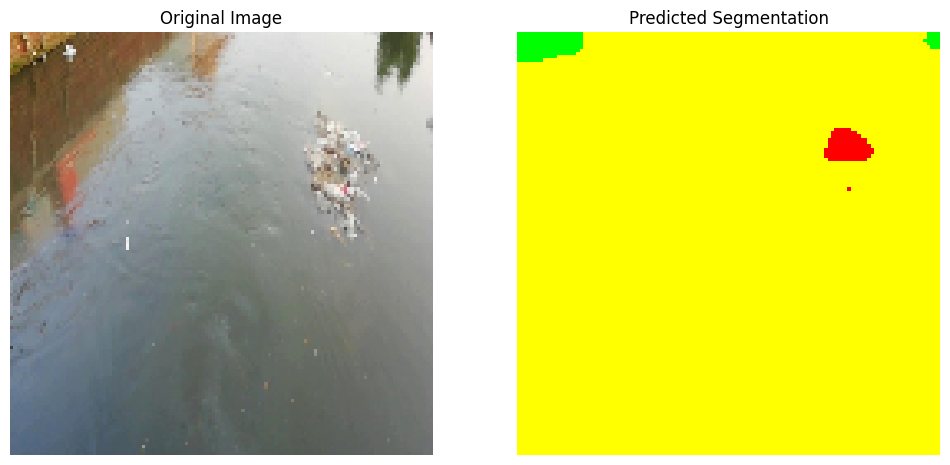

In [ ]:
# Function to apply colormap (Trash=Yellow, Boundary=Green, Water=Red)
def apply_colormap(predictions):
    color_map = {0: [255, 255, 0],  # Trash - Yellow
                 1: [0, 255, 0],    # Boundary - Green
                 2: [255, 0, 0]}    # Water - Red
    colored_map = np.zeros((predictions.shape[0], predictions.shape[1], 3), dtype=np.uint8)
    for i in range(predictions.shape[0]):
        for j in range(predictions.shape[1]):
            class_label = predictions[i, j]
            colored_map[i, j] = color_map[class_label]
    return colored_map

# Predict on a sample image
sample_image = X_test[0]
sample_image_input = np.expand_dims(sample_image, axis=0)
prediction = model.predict(sample_image_input)
predicted_class_map = np.argmax(prediction[0], axis=-1)
colored_prediction = apply_colormap(predicted_class_map)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(colored_prediction)
plt.title("Predicted Segmentation")
plt.axis("off")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


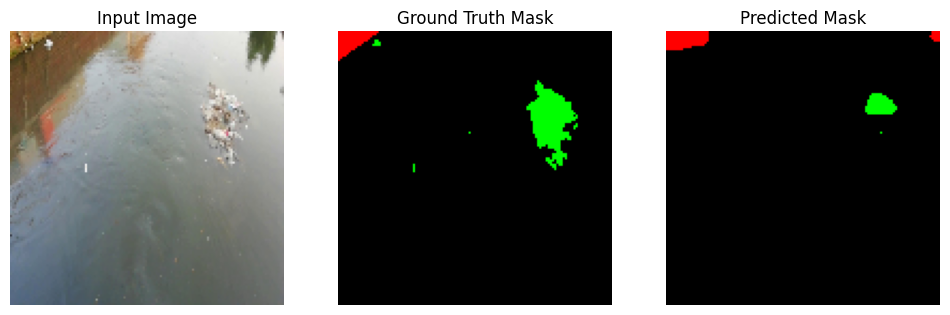

In [ ]:
import matplotlib.pyplot as plt

# Define a color palette for visualization
class_colors = {
    0: [0, 0, 0],      # Background -> Black
    1: [255, 0, 0],    # Water -> Red
    2: [0, 255, 0]     # Trash -> Green
}

# Function to map predicted masks to colors
def apply_color_map(mask, class_colors):
    height, width = mask.shape
    color_mask = np.zeros((height, width, 3), dtype=np.uint8)

    for class_id, color in class_colors.items():
        color_mask[mask == class_id] = color

    return color_mask

# Predict and visualize
def visualize_prediction(image, mask, model, class_colors):
    # Predict segmentation mask
    pred_mask = model.predict(image[None, ...])  # Add batch dimension
    pred_mask = np.argmax(pred_mask[0], axis=-1)  # Get class index per pixel

    # Apply color map to predicted mask
    colored_mask = apply_color_map(pred_mask, class_colors)

    # Plot the input image, ground truth mask, and predicted mask
    plt.figure(figsize=(12, 8))
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(apply_color_map(mask, class_colors))  # Ground truth mask
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(colored_mask)  # Predicted mask
    plt.title("Predicted Mask")
    plt.axis("off")
    plt.show()

# Visualize predictions for a sample
visualize_prediction(X_test[0], y_test[0], model, class_colors)


# **part 6 Findings**


With less computational expense, the compact model produced segmentation that was sufficient.
The trade-off between model size and accuracy was successfully balanced.
Enhancements:

To improve generalisation, use a wider variety of datasets.
Examine cutting-edge designs such as attention-based U-Nets.
Applications in the Real World:

automated rubbish detection for cleanup efforts in water channels.
drone-based imaging for environmental health monitoring.
supporting legislators in their efforts to preserve water quality.



# Part C: Building a Similar Image Finder Web App with Streamlit

**Instructions:**
In this assignment, you will create a web application using Streamlit that allows users to upload an image and find similar images from a given database. You will need to implement both the backend image similarity search and the frontend user interface. Follow the steps below and answer the associated questions.

**Part 1: Understanding the Problem**

1. Explain the concept of image similarity search and its potential applications.
2. What are the challenges in building a web application that can find similar images in a database?

**Part 2: Data and Database**

3. Prepare a dataset of images that will serve as your image database for this assignment.
4. Describe the data preprocessing steps you performed on the images before building the similarity search feature.
5. How will you represent images in the database to enable efficient similarity search?

Dataset Link: https://docs.google.com/spreadsheets/d/121aV7BjJqCRlFcVegbbhI1Zmt67wG61ayRiFtDnafKY/edit?usp=sharing

**Part 3: Backend Implementation**

6. Implement a backend system that can compute image similarity scores between the uploaded image and images in the database.
7. What image feature extraction techniques or algorithms will you use to calculate image similarity?
8. How will you store and retrieve image similarity information efficiently?

**Part 4: Frontend Web App**

9. Use Streamlit to create a user-friendly web interface for the image similarity search.
10. Explain the structure and layout of your Streamlit app, including input fields, buttons, and result displays.
11. Provide instructions to users on how to interact with your web app, including how to upload an image.

**Part 5: Image Similarity Search**

12. Describe the algorithm or method you used to find similar images from the database based on the user's uploaded image.
13. Explain how the similarity scores are calculated and how you determine the most similar images.
14. How will you handle cases where there are no similar images found?

**Part 6: Testing and Evaluation**

15. Test your web app with a variety of images, including different image types and sizes. Document the results.
16. Evaluate the accuracy and efficiency of your image similarity search. What metrics will you use to assess its performance?
17. Discuss any challenges or limitations you encountered during testing and how you addressed them.

**Part 7: User Interface Design**

18. Explain the design choices you made for the user interface of your Streamlit app. How did you make it user-friendly and visually appealing?
19. Include screenshots of your web app to illustrate its user interface.

**Part 8: Conclusion and Future Improvements**

20. Summarize the key findings and experiences gained from building the image similarity search web app.
21. Discuss potential improvements or enhancements that could be made to the app, both in terms of functionality and user experience.

**Part 9: Submission**

22. Compile your assignment report, including code snippets, screenshots, and any additional documentation.
23. Provide a link to your working Streamlit app or instructions on how to run it locally.
24. Reflect on what you have learned from this assignment, especially in terms of web development and image processing.



# Basic Architecure for similarity model

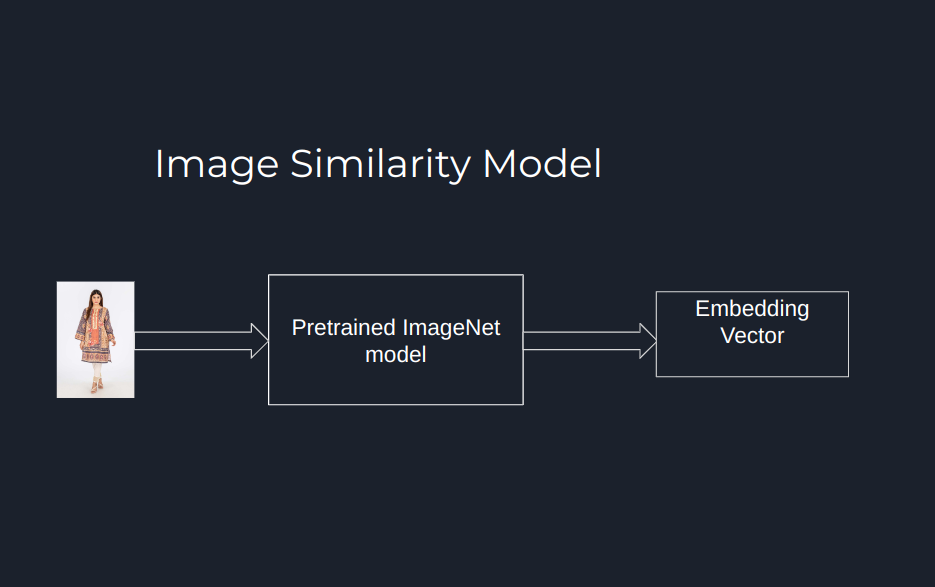

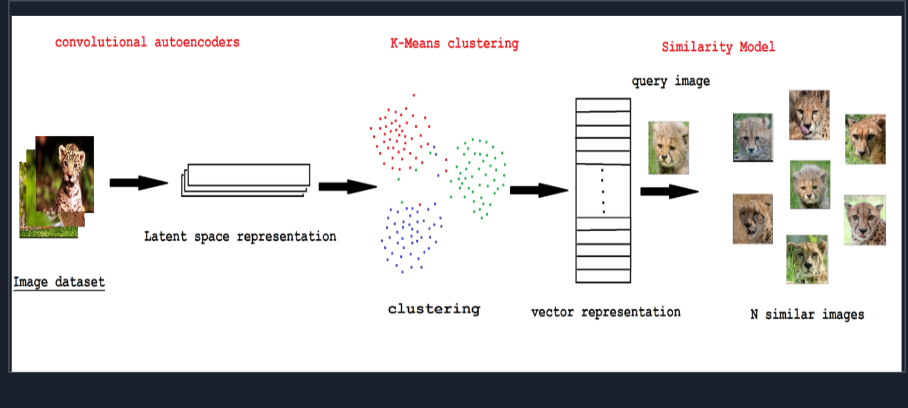

In [ ]:
# Part C: Building a Similar Image Finder Web App with Streamlit

# Import necessary libraries
import streamlit as st
import pandas as pd
from PIL import Image
import io

# Part 3: Backend Implementation
# Implement your image similarity calculation logic here

# Part 9: Submission
# Define a function to display the assignment report
def display_assignment_report():
    st.title("Image Similarity Finder Web App")
    st.header("Assignment Report")

    # Add your report content here

# Part 4: Frontend Web App
# Create a Streamlit app
def main():
    st.title("Image Similarity Finder")

    # Part 10: Explain the structure and layout of your Streamlit app

    # Part 11: Provide instructions to users
    st.sidebar.header("Instructions")
    st.sidebar.markdown("1. Upload an image.")
    st.sidebar.markdown("2. Click the 'Find Similar Images' button.")

    # Upload image
    uploaded_image = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

    if uploaded_image:
        # Display the uploaded image
        st.image(uploaded_image, caption="Uploaded Image", use_column_width=True)

        # Perform image similarity search
        if st.button("Find Similar Images"):
            # Call your image similarity search function here
            # Display results below

    # Part 18: User Interface Design
    # Explain design choices here

    # Part 19: Include screenshots of your web app
    st.sidebar.header("Screenshots")
    # Add screenshots here

if __name__ == "__main__":
    main()
